In [1]:
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt

# 1. Process & Explore data

In [2]:
# We need to extract the times from the data files 
# and create a matrix using (O,D) pairs with times
tt1 = pd.read_csv('travel_times_15_17.csv')
tt2 = pd.read_csv('travel_times_17_19.csv')
tt3 = pd.read_csv('travel_times_19_21.csv')
tt1.head()

,departure_time,origin_station_id,origin_name,origin_lat,origin_lon,dest_station_id,dest_name,dest_lat,dest_lon,distance_meters,duration_seconds,duration_minutes,duration_in_traffic_seconds,duration_in_traffic_minutes,status
0,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589152,"Fribourg, Mon-Repos",46.806711,7.172136,270,35,0.58,42,0.70,OK
1,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589138,"Fribourg, Cité-Jardins",46.809385,7.170446,659,86,1.43,117,1.95,OK
2,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8591766,"Fribourg, Boschung",46.811451,7.171016,1013,138,2.30,174,2.90,OK
3,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8587255,"Fribourg, Tilleul/Cathédrale",46.806090,7.161261,3788,445,7.42,506,8.43,OK
4,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589161,"Fribourg, St-Pierre",46.803911,7.155266,4335,561,9.35,622,10.37,OK


* Number of trips

In [3]:
shape1 = tt1.shape[0]
shape2 = tt2.shape[0]
shape3 = tt3.shape[0]

print("Number of trips between 15-17: ",shape1)
print("Number of trips between 17-19: ",shape2)
print("Number of trips between 19-21: ",shape3)

Number of trips between 15-17:  5684
Number of trips between 17-19:  10556
Number of trips between 19-21:  5684


* Set with origins and set with destinations from data above

In [4]:
destinations = tt1['dest_name']
origins = tt1['origin_name']
print(destinations [:20])
print(origins[:20])

0                Fribourg, Mon-Repos
1             Fribourg, Cité-Jardins
2                 Fribourg, Boschung
3       Fribourg, Tilleul/Cathédrale
4                Fribourg, St-Pierre
5        Fribourg/Freiburg, Pl. Gare
6      Villars-sur-Glâne, Méridienne
7          Villars-sur-Glâne, Moncor
8     Villars-sur-Glâne, Belle-Croix
9                   Fribourg, Chaley
10            Fribourg, Cité-Jardins
11                Fribourg, Boschung
12      Fribourg, Tilleul/Cathédrale
13               Fribourg, St-Pierre
14       Fribourg/Freiburg, Pl. Gare
15     Villars-sur-Glâne, Méridienne
16         Villars-sur-Glâne, Moncor
17    Villars-sur-Glâne, Belle-Croix
18                  Fribourg, Chaley
19               Fribourg, Mon-Repos
Name: dest_name, dtype: object
0           Fribourg, Chaley
1           Fribourg, Chaley
2           Fribourg, Chaley
3           Fribourg, Chaley
4           Fribourg, Chaley
5           Fribourg, Chaley
6           Fribourg, Chaley
7           Fribourg, Chal

In [5]:
tt1_copy = tt1.copy()

# Load Data
tt1 = pd.read_csv('travel_times_15_17.csv')
tt1['departure_time'] = pd.to_datetime(tt1['departure_time'])


# Create explicit ID columns in your base DataFrame
tt1_copy['p_id'] = tt1_copy.index  # Pickup Node 1 to n
tt1_copy['d_id'] = tt1_copy.index + len(tt1_copy)  # Dropoff Node n+1 to 2n

# Number of requests (n)
n = len(tt1_copy)

* Matrix with (O,D) pairs: time I think (distance maybe?)
* MILP only optimize every x minutes so only take x minutes

In [6]:
# 2. Build Travel Matrix (Dictionary for O(1) lookups)
travel_matrix = {}
for _, row in tt1.iterrows():
    travel_matrix[(row['origin_station_id'], row['dest_station_id'])] = row['duration_in_traffic_minutes']

all_stations = set(tt1['origin_station_id']).union(set(tt1['dest_station_id']))
for s in all_stations:
    travel_matrix[(s, s)] = 0.0

# 2. Define parameters

In [7]:
# 1. Define Fleet (3 types, 11 buses total)
# Type 4: 5 buses | Type 6: 4 buses | Type 8: 2 buses
n1 = 20
n2 = 6
n3 = 1
bus_capacities = [4]*n1 + [6]*n2 + [8]*n3
bus_costs = [20]*n1 + [50]*n2 + [70]*n3  # Cost per minute
buses = range(len(bus_capacities))

# 2. Project Parameters
PARAMS = {
    'b1': 1,
    'b2': 1,
    'b3': 1,
    'time_window': 15,
    'max_req_per_window': 15, # STAY UNDER 2000 VARIABLES
    'buses': [0, 1, 2, 3],
    'bus_capacity': bus_capacities, # 4 buses of varying sizes
    'cost_per_bus': bus_costs,
    'cost_reject': 200,
    'si': 2,                 # Service time to board/alight
    'max_transfer_time': 10, # Prune arcs: Don't drive >10 mins empty
    'max_ride_time': 25,     # L_i: Max time a passenger stays in bus
    'M_time': 60,            # Big-M for time (tightened for speed)
    'M_load': 10             # Big-M for load (tightened for speed)
}

* Number of passenger: Poisson distribution

In [8]:
# Let's add the number of passenger as a list of random values
vehicules = np.zeros(tt1.shape[0])
print("Number of trips: ",tt1.shape[0])

# Always get same random values
np.random.seed(42)

# Poisson distribution around (usually most people) and maximum value of people is 8
passengers = np.random.poisson(lam=4, size=tt1.shape[0])
passengers = np.clip(passengers, 1, 8)

# Helper function: I need to look at what vehicule each group actually need to be assigned to:
for i, pax in enumerate(passengers):
    for cap in bus_capacities:
        if pax <= cap:
            vehicules[i] = cap
            break # stop at the first bus that fits

print(passengers[:20])
print("Mean number of passengers per vehicule: ",np.mean(passengers))
print(vehicules[:20])
print("Mean vehicule size: ", np.mean(vehicules))

Number of trips:  5684
[5 4 4 4 2 5 2 5 3 5 7 1 4 3 3 1 5 4 6 7]
Mean number of passengers per vehicule:  3.977480647431386
[6. 4. 4. 4. 4. 6. 4. 6. 4. 6. 8. 4. 4. 4. 4. 4. 6. 4. 6. 8.]
Mean vehicule size:  4.963406052076003


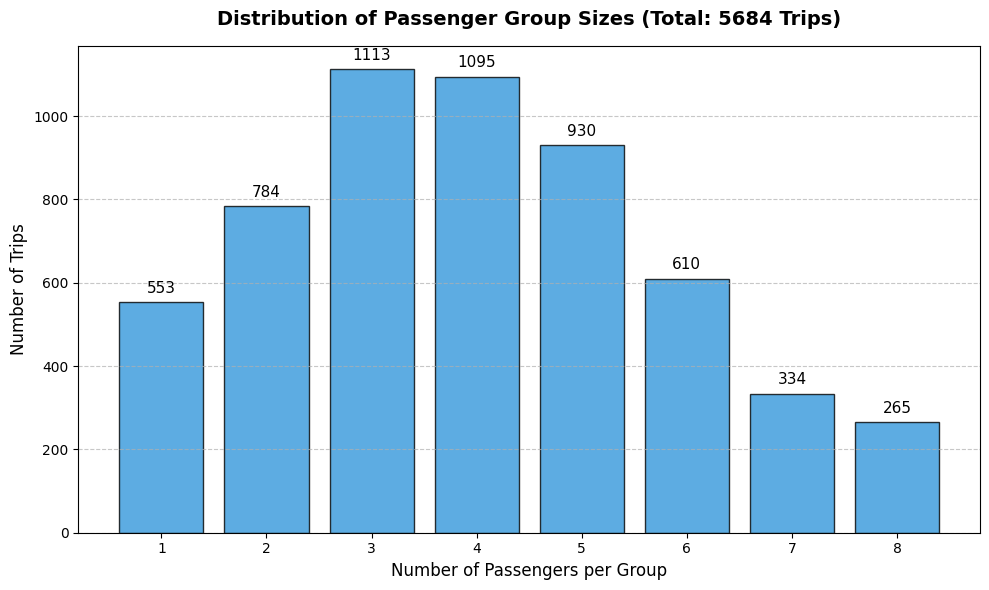

In [9]:
# 2. Count the occurrences of each group size
unique, counts = np.unique(passengers, return_counts=True)

# 3. Create the Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(unique, counts, color='#3498db', edgecolor='black', alpha=0.8)

# 4. Formatting and Labels
ax.set_title('Distribution of Passenger Group Sizes (Total: 5684 Trips)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Passengers per Group', fontsize=12)
ax.set_ylabel('Number of Trips', fontsize=12)
ax.set_xticks(range(1, 9)) # Ensure all ticks from 1 to 8 are shown

# 5. Add exact numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 15, int(yval), ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

* Window

In [10]:
""" start_time = tt1_copy['departure_time'].min().floor('15min')
end_time = tt1_copy['departure_time'].max().ceil('15min')
time_slots = pd.date_range(start=start_time, end=end_time, freq=f'{time_window}min')
 
all_solutions = {}
 
for idx, current_time in enumerate(time_slots[:-1]):
    
    next_time = current_time + pd.Timedelta(minutes=time_window)
    
    print(f"WINDOW {idx+1}/{len(time_slots)-1}: {current_time.strftime('%H:%M')} - {next_time.strftime('%H:%M')}")
    
    # Extract trips in this window
    mask = (tt1_copy['departure_time'] >= current_time) & (tt1_copy['departure_time'] < next_time)
    window_df = tt1_copy[mask].copy()
    
    if len(window_df) == 0:
        print("No trips in this window")
        continue
    
    window_requests = window_df.index.tolist()
    print(f"Requests: {len(window_requests)}")
    
    # Create arcs: all i→j pairs where i,j ∈ nodes, i≠j
    window_arcs = [(i, j) for i in all_nodes for j in all_nodes if i != j]

     """

' start_time = tt1_copy[\'departure_time\'].min().floor(\'15min\')\nend_time = tt1_copy[\'departure_time\'].max().ceil(\'15min\')\ntime_slots = pd.date_range(start=start_time, end=end_time, freq=f\'{time_window}min\')\n\nall_solutions = {}\n\nfor idx, current_time in enumerate(time_slots[:-1]):\n\n    next_time = current_time + pd.Timedelta(minutes=time_window)\n\n    print(f"WINDOW {idx+1}/{len(time_slots)-1}: {current_time.strftime(\'%H:%M\')} - {next_time.strftime(\'%H:%M\')}")\n\n    # Extract trips in this window\n    mask = (tt1_copy[\'departure_time\'] >= current_time) & (tt1_copy[\'departure_time\'] < next_time)\n    window_df = tt1_copy[mask].copy()\n\n    if len(window_df) == 0:\n        print("No trips in this window")\n        continue\n\n    window_requests = window_df.index.tolist()\n    print(f"Requests: {len(window_requests)}")\n\n    # Create arcs: all i→j pairs where i,j ∈ nodes, i≠j\n    window_arcs = [(i, j) for i in all_nodes for j in all_nodes if i != j]\n\n     '

# 3. Model definition

* Create create window and loop throught window

In [11]:
def optimize_assignment_window(window_df, window_passengers, capacities, costs, params, time_label):
    """
    Assigns groups to buses. 1 Group per bus. No pooling.
    Includes Variable Pruning to respect Gurobi Free License limits.
    """
    m = gp.Model(f"Assignment_{time_label}")
    m.setParam('OutputFlag', 0)

    requests = window_df.index.tolist()
    buses = range(len(capacities))

    # --- VARIABLE PRUNING ---
    x = {}
    for r in requests:
        group_size = window_passengers[r]
        for k in buses:
            if group_size <= capacities[k]:
                # Only add variable if assignment is physically possible
                x[r, k] = m.addVar(vtype=GRB.BINARY, name=f"x_{r}_{k}")

    # --- OBJECTIVE ---
    obj_op = gp.quicksum(
        costs[k] * window_df.loc[r, 'duration_in_traffic_minutes'] * x[r, k]
        for (r, k) in x.keys()
    )

    obj_reject = params['cost_reject'] * gp.quicksum(
        1 - gp.quicksum(x[r, k] for k in buses if (r, k) in x) 
        for r in requests
    )

    m.setObjective(params['b1'] * obj_op + params['b2'] * obj_reject, GRB.MINIMIZE)

    # --- CONSTRAINTS ---
    for r in requests:
        valid_buses_for_req = [x[r, k] for k in buses if (r, k) in x]
        if valid_buses_for_req:
            m.addConstr(gp.quicksum(valid_buses_for_req) <= 1)

    for k in buses:
        valid_reqs_for_bus = [x[r, k] for r in requests if (r, k) in x]
        if valid_reqs_for_bus:
            m.addConstr(gp.quicksum(valid_reqs_for_bus) <= 1)

    m.optimize()

    # --- EXTRACT THE ACTUAL USED CAPACITIES ---
    if m.status == GRB.OPTIMAL:
        served = 0
        used_capacities = []
        served_group_sizes = []
        
        # Loop through all valid combinations
        for (r, k), var in x.items():
            if var.X > 0.5:  # If Gurobi set this binary variable to 1
                served += 1
                used_capacities.append(capacities[k])
                served_group_sizes.append(window_passengers[r])
                
        return {
            "status": "Optimal", 
            "served": served, 
            "total": len(requests), 
            "obj": m.ObjVal,
            "used_caps": used_capacities,           
            "served_groups": served_group_sizes     
        }
        
    return {"status": "No Solution", "served": 0, "total": len(requests), "obj": 0, "used_caps": [], "served_groups": []}

In [12]:

# Force conversion again just to be safe
tt1['departure_time'] = pd.to_datetime(tt1['departure_time'])

time_slots = pd.date_range(
    start=tt1['departure_time'].min().floor(f"{PARAMS['time_window']}min"), 
    end=tt1['departure_time'].max().ceil(f"{PARAMS['time_window']}min"), 
    freq=f"{PARAMS['time_window']}min"
)

print(f"Fleet: {len(bus_capacities)} buses available.")
print("-" * 50)

# --- 1. INITIALIZE LISTS TO STORE DATA ---
results_data = []
all_used_caps = []
all_served_groups = []

for current_time in time_slots[:-1]:
    next_time = current_time + pd.Timedelta(minutes=PARAMS['time_window'])
    
    mask = (tt1['departure_time'] >= current_time) & (tt1['departure_time'] < next_time)
    window_df = tt1[mask].copy()
    
    if window_df.empty: continue
        
    # --- STAY UNDER GUROBI LIMITS --- 
    limit = 50
    if len(window_df) > limit:
        window_df = window_df.head(limit) # Cap at 100 requests per window
        
    window_pax = {idx: passengers[idx] for idx in window_df.index}
    time_str = current_time.strftime('%H:%M')
    
    result = optimize_assignment_window(window_df, window_pax, bus_capacities, bus_costs, PARAMS, time_str)
    
    # --- GET THE EXACT CAPACITIES USED IN THIS WINDOW ---
    current_used_caps = result.get('used_caps', [])
    
    # Count how many of each type were dispatched
    used_4 = current_used_caps.count(4)
    used_6 = current_used_caps.count(6)
    used_8 = current_used_caps.count(8)
    
    # --- 2. SAVE THE RESULTS ---
    results_data.append({
        'Time': time_str,
        'Total Requests': result['total'],
        'Served': result['served'],
        'Missed': result['total'] - result['served'], 
        'Score': result['obj'],
        '4-Seaters Used': used_4, 
        '6-Seaters Used': used_6,  
        '8-Seaters Used': used_8   
    })
    
    # Aggregate the capacity data for the whole day
    all_used_caps.extend(current_used_caps)
    all_served_groups.extend(result.get('served_groups', []))
    
    # Print the breakdown so you can see it live!
    print(f"[{time_str}] Requests: {result['total']:02d} | Served: {result['served']:02d} | "
          f"Buses -> [4-seat: {used_4}, 6-seat: {used_6}, 8-seat: {used_8}] | Score: {result['obj']:.2f}")

Fleet: 27 buses available.
--------------------------------------------------
Restricted license - for non-production use only - expires 2027-11-29
[15:00] Requests: 50 | Served: 26 | Buses -> [4-seat: 19, 6-seat: 6, 8-seat: 1] | Score: 7630.60
[15:15] Requests: 50 | Served: 22 | Buses -> [4-seat: 20, 6-seat: 1, 8-seat: 1] | Score: 7541.60
[15:30] Requests: 50 | Served: 24 | Buses -> [4-seat: 20, 6-seat: 4, 8-seat: 0] | Score: 7235.50
[16:00] Requests: 50 | Served: 24 | Buses -> [4-seat: 19, 6-seat: 4, 8-seat: 1] | Score: 7349.10
[16:15] Requests: 50 | Served: 21 | Buses -> [4-seat: 20, 6-seat: 0, 8-seat: 1] | Score: 7524.60
[16:30] Requests: 50 | Served: 21 | Buses -> [4-seat: 14, 6-seat: 6, 8-seat: 1] | Score: 7785.40


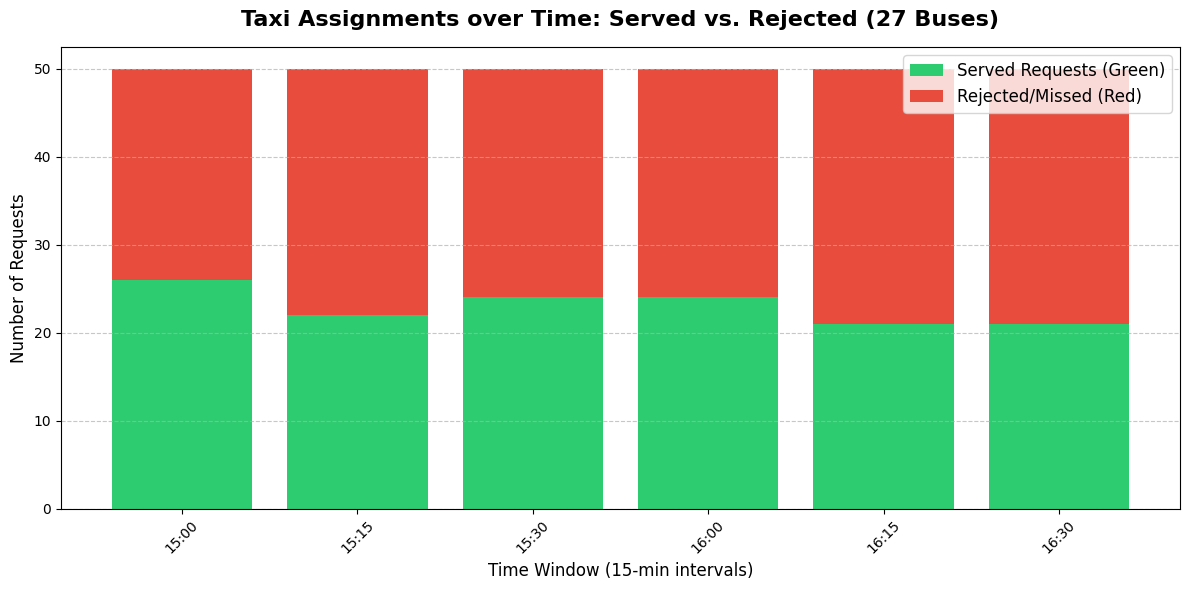

In [13]:
# --- 3. CREATE THE PLOT ---
df_plot = pd.DataFrame(results_data)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Served (Green) and Missed (Red) stacked on top of each other
ax.bar(df_plot['Time'], df_plot['Served'], label='Served Requests (Green)', color='#2ecc71')
ax.bar(df_plot['Time'], df_plot['Missed'], bottom=df_plot['Served'], label='Rejected/Missed (Red)', color='#e74c3c')

# Formatting
ax.set_title(f'Taxi Assignments over Time: Served vs. Rejected ({len(bus_capacities)} Buses)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Time Window (15-min intervals)', fontsize=12)
ax.set_ylabel('Number of Requests', fontsize=12)
ax.legend(fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()